# Operação Lava-Imóvel
## Investigação de possíveis esquemas de lavagem de dinheiro no mercado imobiliário

Este notebook apresenta uma análise investigativa baseada em dados de transações imobiliárias
ocorridas entre 2022 e 2024 na cidade de Fortaleza.

O objetivo é identificar **padrões suspeitos de lavagem de dinheiro**, utilizando técnicas
de análise de dados com Python e Pandas.

A investigação se baseia em três bases de dados:

- **Transações imobiliárias**
- **Perfil dos compradores**
- **Histórico de preços de referência por bairro**

Durante a análise buscamos evidências de:

• imóveis vendidos muito acima do preço de mercado  
• compradores com renda incompatível com os imóveis adquiridos  
• compradores adquirindo múltiplos imóveis  
• revendas rápidas com grandes lucros  
• repetição de CNPJs intermediando transações  
• concentração de pagamentos à vista

Cada etapa da investigação será apresentada com análises estatísticas
e visualizações que ajudam a revelar possíveis padrões suspeitos.


## Etapa 1 — Carregamento dos dados

Nesta etapa carregamos os três datasets utilizados na investigação.

As bases incluem:

**1. Perfil dos compradores**
Informações socioeconômicas como renda, profissão e número de imóveis adquiridos.

**2. Histórico de preços por bairro**
Dados agregados do mercado imobiliário que servem como referência
para identificar imóveis vendidos acima do valor esperado.

**3. Transações imobiliárias**
Contém informações detalhadas sobre cada negociação realizada,
incluindo preço, área do imóvel, forma de pagamento e comprador.

A partir dessas bases será possível cruzar informações e detectar
comportamentos fora do padrão esperado no mercado imobiliário.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

perfil_compradores = "../data/projeto_09_compradores_perfil.csv"
precos_bairro = "../data/projeto_09_historico_precos_bairro.csv"
mercado_imobiliario = "../data/projeto_09_mercado_imobiliario.csv"

df_compradores = pd.read_csv(perfil_compradores, delimiter=',')
print('Exibindo perfil de compradores')
print(df_compradores.head())

df_precos_bairros = pd.read_csv(precos_bairro, delimiter=',')
print('Exibindo preços dos bairros')
print(df_precos_bairros.head())

df_mercado_imobiliario = pd.read_csv(mercado_imobiliario, delimiter=',')
print('Exibindo mercado imobiliario')
print(df_mercado_imobiliario.head())

Exibindo perfil de compradores
  comprador_id  renda_mensal_declarada  idade estado_civil    profissao  \
0    CPF-03931                 8015.56     46       Casado     Advogado   
1    CPF-07445                 4047.78     55   Divorciado     Servidor   
2    CPF-01663                 8790.44     55       Casado   Empresário   
3    CPF-04479                 8191.80     61       Casado  Comerciante   
4    CPF-02381                 9396.28     45       Casado       Médico   

   numero_imoveis_adquiridos  possui_restricao_credito  pep  
0                          1                         0    0  
1                          1                         0    0  
2                          1                         0    0  
3                          2                         0    0  
4                          1                         0    1  
Exibindo preços dos bairros
     bairro   ano  trimestre  preco_m2_referencia  numero_transacoes  \
0  Meireles  2022          1             11983

Exibindo mercado imobiliario
  transacao_id  imovel_id     bairro  tipo_imovel  area_m2  quartos condicao  \
0     TX-00001  IMO-00001     Centro  Apartamento       92        3    Usado   
1     TX-00002  IMO-00002  Messejana    Cobertura      215        3    Usado   
2     TX-00003  IMO-00003  Parangaba  Apartamento       62        3     Novo   
3     TX-00004  IMO-00004  Maracanaú  Apartamento       53        2    Usado   
4     TX-00005  IMO-00005  Maraponga  Apartamento       70        3     Novo   

   preco_total  preco_m2 comprador_id comprador_cnpj forma_pagamento  \
0    418313.16   4546.88    CPF-02925            NaN         À vista   
1    736733.31   3426.67    CPF-02069            NaN   Financiamento   
2    295173.19   4760.86    CPF-02157            NaN   Financiamento   
3    153461.20   2895.49    CPF-03428            NaN   Financiamento   
4    331702.68   4738.61    CPF-00673            NaN         À vista   

   ano_transacao  mes_transacao  dias_no_mercado  
0     

## Etapa 2 — Limpeza e preparação dos dados

Antes de iniciar a análise investigativa é necessário realizar
o tratamento inicial dos dados.

Nesta etapa realizamos:

• tratamento de valores nulos  
• conversão de tipos de dados  
• criação de novas variáveis úteis para análise  
• preparação de campos para investigação temporal  

Também criamos uma coluna de **data da transação**, que permitirá
analisar possíveis revendas rápidas de imóveis — um comportamento
frequentemente associado a esquemas de lavagem de dinheiro.


In [46]:
df_mercado_imobiliario["dias_no_mercado"] = (df_mercado_imobiliario["dias_no_mercado"].fillna(0).astype(int))

df_mercado_imobiliario["CNPJ OK"] = df_mercado_imobiliario["comprador_cnpj"]

df_mercado_imobiliario["comprador_cnpj"] = (df_mercado_imobiliario["comprador_cnpj"].notna().map({True: "sim", False: "nao"}))

df_mercado_imobiliario["data_transacao"] = pd.to_datetime(df_mercado_imobiliario["ano_transacao"].astype(str) + "-" +df_mercado_imobiliario["mes_transacao"].astype(str))
print('\n Exibindo mercado imobiliario com tratamento\n')
print(df_mercado_imobiliario.head())


 Exibindo mercado imobiliario com tratamento

  transacao_id  imovel_id     bairro  tipo_imovel  area_m2  quartos condicao  \
0     TX-00001  IMO-00001     Centro  Apartamento       92        3    Usado   
1     TX-00002  IMO-00002  Messejana    Cobertura      215        3    Usado   
2     TX-00003  IMO-00003  Parangaba  Apartamento       62        3     Novo   
3     TX-00004  IMO-00004  Maracanaú  Apartamento       53        2    Usado   
4     TX-00005  IMO-00005  Maraponga  Apartamento       70        3     Novo   

   preco_total  preco_m2 comprador_id comprador_cnpj forma_pagamento  \
0    418313.16   4546.88    CPF-02925            nao         À vista   
1    736733.31   3426.67    CPF-02069            nao   Financiamento   
2    295173.19   4760.86    CPF-02157            nao   Financiamento   
3    153461.20   2895.49    CPF-03428            nao   Financiamento   
4    331702.68   4738.61    CPF-00673            nao         À vista   

   ano_transacao  mes_transacao  dias_n

## Etapa 3 — Consolidação das bases de dados

Nesta etapa realizamos o cruzamento das três bases disponíveis.

O objetivo é criar um **dataset consolidado**, reunindo informações
sobre:

• características do imóvel  
• perfil do comprador  
• preço médio de mercado do bairro  

Esse cruzamento é essencial para permitir análises investigativas,
como por exemplo comparar o preço pago em um imóvel com o preço
de referência daquele bairro.

A base final utilizada na investigação será chamada **df_master**.


In [49]:
df_consolidado = pd.merge(df_compradores,df_mercado_imobiliario,on='comprador_id',how='inner')

print(df_consolidado.head())

# média de preço por bairro
media_por_bairro = (df_precos_bairros.groupby("bairro")["preco_m2_referencia"].mean().reset_index())

# garantindo tipo float
media_por_bairro["preco_m2_referencia"] = (media_por_bairro["preco_m2_referencia"].astype(float))

# merge final
df_master = pd.merge(df_consolidado,media_por_bairro,on="bairro",how="left")

print("Colunas:", df_master.columns)
print(df_master.head())

  comprador_id  renda_mensal_declarada  idade estado_civil    profissao  \
0    CPF-03931                 8015.56     46       Casado     Advogado   
1    CPF-07445                 4047.78     55   Divorciado     Servidor   
2    CPF-01663                 8790.44     55       Casado   Empresário   
3    CPF-04479                 8191.80     61       Casado  Comerciante   
4    CPF-02381                 9396.28     45       Casado       Médico   

   numero_imoveis_adquiridos  possui_restricao_credito  pep transacao_id  \
0                          1                         0    0     TX-01622   
1                          1                         0    0     TX-02830   
2                          1                         0    0     TX-00129   
3                          2                         0    0     TX-01609   
4                          1                         0    1     TX-03457   

   imovel_id  ... condicao preco_total  preco_m2  comprador_cnpj  \
0  IMO-01622  ...    Usa

## Investigação 1 — Imóveis vendidos acima do valor de mercado

Uma das formas comuns de lavagem de dinheiro no setor imobiliário
é a **compra de imóveis com preços artificialmente inflados**.

Nesse tipo de operação, valores ilegais são incorporados ao preço
do imóvel para transformar dinheiro ilícito em um ativo aparentemente legítimo.

Para investigar esse padrão:

1. Comparamos o **preço por metro quadrado da transação**
2. Com o **preço médio de referência do bairro**

Se a diferença estiver entre **40% e 60% acima do valor de mercado**,
a transação será marcada como **suspeita de sobrepreço**.


In [50]:
df_master['variação'] = (df_master['preco_m2'] /df_master['preco_m2_referencia']) - 1

df_master['é suspeito?'] = np.where((df_master['variação'] >= 0.40) & (df_master['variação'] <= 0.60),'SIM','NÃO')

df_suspeitos_sobrepreco = df_master[['transacao_id', 'comprador_id', 'bairro', 'variação','é suspeito?','profissao']]
print(df_suspeitos_sobrepreco.head(10))

  transacao_id comprador_id     bairro  variação é suspeito?    profissao
0     TX-01622    CPF-03931  Maraponga     -0.10         NÃO     Advogado
1     TX-02830    CPF-07445     Centro      0.06         NÃO     Servidor
2     TX-00129    CPF-01663    Montese     -0.06         NÃO   Empresário
3     TX-01609    CPF-04479   Meireles      0.02         NÃO  Comerciante
4     TX-03457    CPF-02381     Centro      0.49         SIM       Médico
5     TX-01962    CPF-04945  Messejana      0.07         NÃO     Autônomo
6     TX-02242    CPF-00561    Aldeota      0.14         NÃO     Autônomo
7     TX-00421    CPF-02687    Benfica      0.22         NÃO  Comerciante
8     TX-03155    CPF-00378    Eusébio      0.03         NÃO       Médico
9     TX-00324    CPF-00385  Maraponga     -0.09         NÃO     Servidor


### Visualização — Transações suspeitas por profissão

Após identificar imóveis com sobrepreço,
analisamos o perfil profissional dos compradores.

Essa visualização permite verificar se determinados grupos
profissionais aparecem com maior frequência nas transações
consideradas suspeitas.


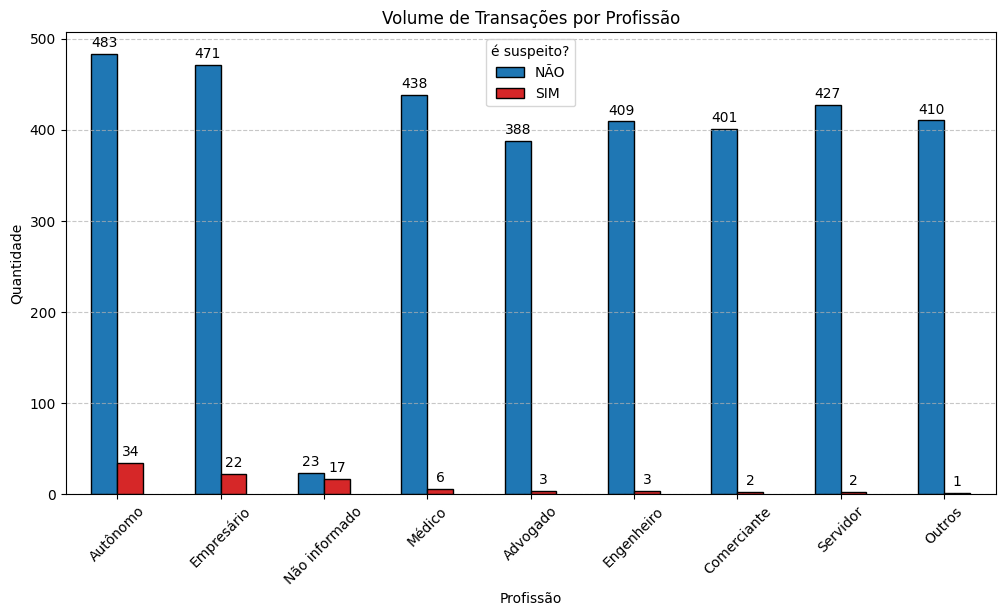

In [51]:
dados_grafico = pd.crosstab(df_master['profissao'],df_master['é suspeito?'])

dados_grafico = dados_grafico.sort_values(by='SIM',ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

dados_grafico.plot(kind='bar',ax=ax,color=['#1f77b4', '#d62728'],edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Volume de Transações por Profissão')
plt.xlabel('Profissão')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribuição da renda declarada dos compradores

Antes de investigar renda incompatível,
é importante entender como a renda dos compradores
se distribui na base de dados.

Esse gráfico mostra a **distribuição da renda mensal declarada**,
permitindo identificar concentrações de renda e possíveis outliers.


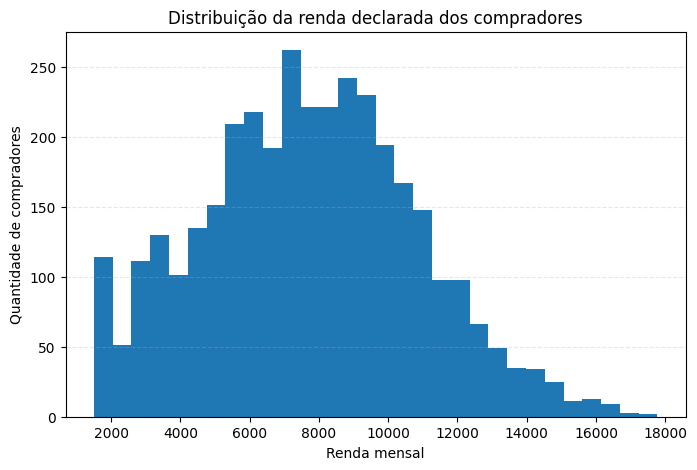

In [52]:
plt.figure(figsize=(8,5))
plt.hist(df_master['renda_mensal_declarada'], bins=30)
plt.title("Distribuição da renda declarada dos compradores")
plt.xlabel("Renda mensal")
plt.ylabel("Quantidade de compradores")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Investigação 2 — Renda incompatível com o valor do imóvel

Outro padrão típico de lavagem de dinheiro é a aquisição
de imóveis de alto valor por compradores com **renda declarada muito baixa**.

Nesta análise identificamos compradores que:

• adquiriram imóveis acima de **R$ 1.000.000**  
• possuem renda mensal declarada inferior a **R$ 5.000**

Esse comportamento pode indicar uso de recursos de origem
não declarada ou terceiros financiando a compra.


     comprador_id  renda_mensal_declarada  preco_total compra_suspeita?
0       CPF-03931                 8015.56    110495.80              NÃO
1       CPF-07445                 4047.78    564654.29              NÃO
2       CPF-01663                 8790.44    527718.19              NÃO
3       CPF-04479                 8191.80    258916.93              NÃO
4       CPF-02381                 9396.28    514095.46              NÃO
...           ...                     ...          ...              ...
3535    CPF-03338                 8466.55    530745.12              NÃO
3536    CPF-01373                11316.16    509178.69              NÃO
3537    CPF-01373                11316.16    971796.61              NÃO
3538    CPF-04854                 8073.48    391405.86              NÃO
3539    CPF-04770                12266.98   1066524.47              NÃO

[3540 rows x 4 columns]


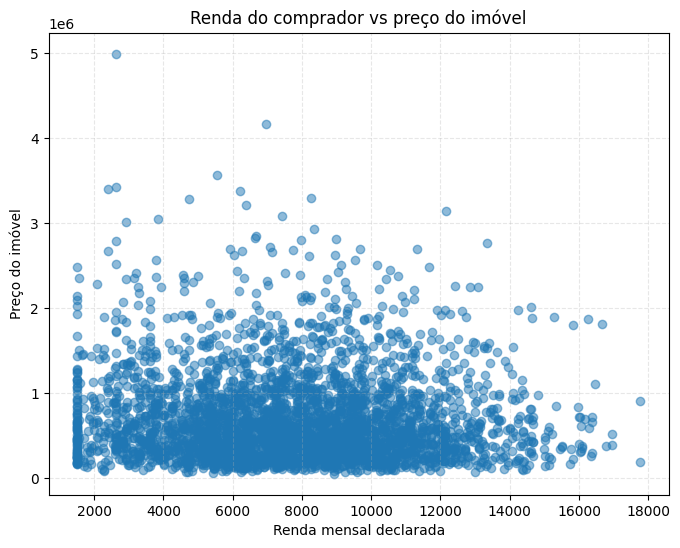

In [53]:
df_master['compra_suspeita?'] = np.where((df_master['preco_total'] >= 1000000) & (df_master['renda_mensal_declarada'] < 5000),'SIM','NÃO')

print(df_master[['comprador_id','renda_mensal_declarada','preco_total','compra_suspeita?']])

plt.figure(figsize=(8,6))

plt.scatter(df_master['renda_mensal_declarada'],df_master['preco_total'],alpha=0.5)

plt.title("Renda do comprador vs preço do imóvel")
plt.xlabel("Renda mensal declarada")
plt.ylabel("Preço do imóvel")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Relação entre renda declarada e valor do imóvel

Este gráfico mostra a relação entre:

• renda mensal declarada do comprador  
• preço total do imóvel adquirido  

Pontos localizados na região de **baixa renda e alto valor de imóvel**
podem representar potenciais casos de renda incompatível.


In [54]:
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

visao_suspeitos = (df_master.groupby('compra_suspeita?').agg({'renda_mensal_declarada':'sum','preco_total':'sum'}).reset_index())

visao_suspeitos.columns = ['SUSPEITO?','Soma renda','Soma investimento']

visao_suspeitos['investimento/renda'] = (visao_suspeitos['Soma investimento'] /visao_suspeitos['Soma renda'])

print(visao_suspeitos)

  SUSPEITO?  Soma renda  Soma investimento  investimento/renda
0       NÃO 26777264.57      2176171574.17               81.27
1       SIM   540586.18       264601142.01              489.47


## Investigação 3 — Compradores com múltiplos imóveis

Nesta etapa buscamos compradores que adquiriram **três ou mais imóveis**.

A aquisição frequente de imóveis pode indicar:

• atividade legítima de investimento  
• ou tentativa de movimentação de capital ilícito por meio de ativos imobiliários

A análise também considera o perfil profissional desses compradores.


maior_3_aquisicoes?  NÃO  SIM
profissao                    
Advogado             323    0
Autônomo             351   10
Comerciante          331    0
Empresário           344    6
Engenheiro           334    0
Médico               363    0
Não informado          0    4
Outros               331    0
Servidor             334    0


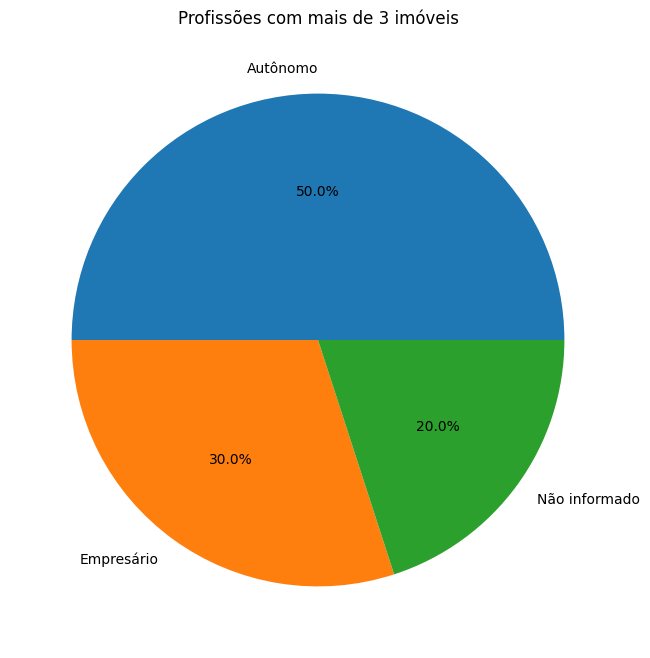

In [55]:
df_master['maior_3_aquisicoes?'] = np.where(df_master['numero_imoveis_adquiridos'] >= 3,'SIM','NÃO')

visao_profissao = (df_master.groupby(['profissao','maior_3_aquisicoes?'])['comprador_id'].nunique().unstack(fill_value=0))

print(visao_profissao)

dados_sim = visao_profissao['SIM'][visao_profissao['SIM'] > 0]

plt.figure(figsize=(8,8))
plt.pie(dados_sim,labels=dados_sim.index,autopct='%1.1f%%')
plt.title('Profissões com mais de 3 imóveis')
plt.show()

## Investigação 4 — Revenda rápida de imóveis

Outra estratégia comum em esquemas de lavagem de dinheiro
é a **revenda rápida de imóveis com grandes margens de lucro**.

Para investigar esse padrão:

1. identificamos imóveis negociados mais de uma vez  
2. calculamos a variação de preço entre as transações  
3. marcamos como suspeitos casos com **lucro superior a 50%**

Esse comportamento pode indicar manipulação artificial de preços.


   imovel_id  valor_minimo  valor_maximo  variacao_pct lucro_suspeito
0  IMO-00042     845693.31    1453005.07         71.81            SIM
1  IMO-00057    1032268.52    1563929.47         51.50            SIM
2  IMO-00174     634815.35    1100545.19         73.36            SIM
3  IMO-00408    1340043.73    2300753.57         71.69            SIM
4  IMO-00414    2364262.64    4169478.33         76.35            SIM


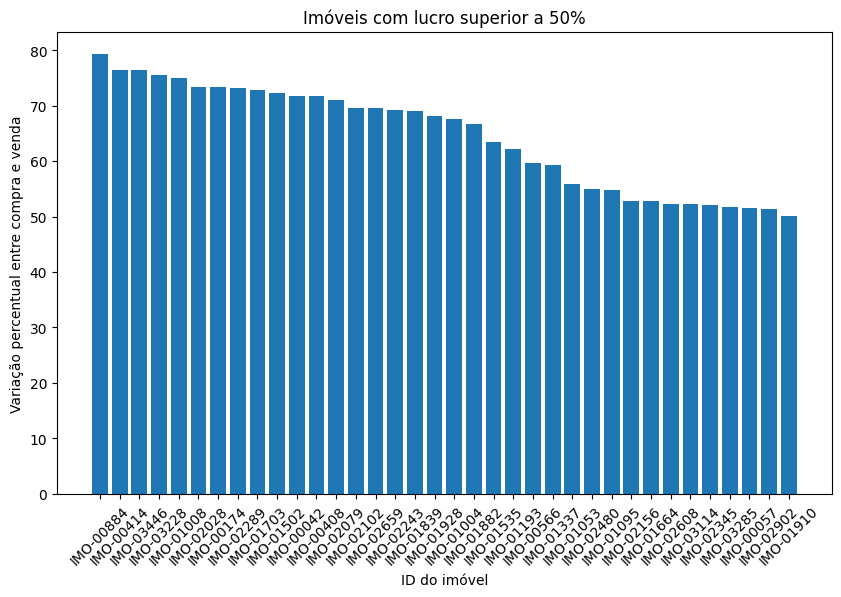

In [57]:
df_master["varias_transacoes"] = (df_master.duplicated(subset="imovel_id",keep=False))

df_master["varias_transacoes"] = df_master["varias_transacoes"].map({True:"SIM",False:"NAO"})

df_varias = df_master[df_master["varias_transacoes"] == "SIM"]

df_revenda = (df_varias.groupby("imovel_id")["preco_total"].agg(["min","max"]).reset_index())

df_revenda.rename(columns={"min":"valor_minimo","max":"valor_maximo"},inplace=True)

df_revenda["variacao_pct"] = ((df_revenda["valor_maximo"] - df_revenda["valor_minimo"]) /df_revenda["valor_minimo"]) * 100

df_revenda["lucro_suspeito"] = np.where(df_revenda["variacao_pct"] > 50,"SIM","NAO")

print(df_revenda.head())

df_master = df_master.sort_values(["imovel_id","data_transacao"])

df_master["dias_revenda"] = (df_master.groupby("imovel_id")["data_transacao"].diff().dt.days)

suspeitos_flip = df_revenda[df_revenda["lucro_suspeito"]=="SIM"]
suspeitos_flip = suspeitos_flip.sort_values("variacao_pct",ascending=False)

plt.figure(figsize=(10,6))
plt.xlabel("ID do imóvel")
plt.ylabel("Variação percentual entre compra e venda")
plt.bar(suspeitos_flip["imovel_id"],suspeitos_flip["variacao_pct"])
plt.title("Imóveis com lucro superior a 50%")
plt.xticks(rotation=45)
plt.show()

## Investigação 5 — CNPJs intermediando transações

Nesta etapa investigamos a participação de empresas nas transações.

O objetivo é identificar se existem **CNPJs recorrentes**
aparecendo em diversas negociações.

Empresas que aparecem frequentemente em transações suspeitas
podem atuar como **intermediários em esquemas de lavagem de dinheiro**.



Total de transações dos 5 principais CNPJs: 80
Média por CNPJ: 16.0
      CNPJ OK  quantidade_transacoes
2  CNPJ-08003                     20
3  CNPJ-08004                     16
0  CNPJ-08001                     15
4  CNPJ-08005                     15
1  CNPJ-08002                     14
Média de transações por CNPJ: 16.0


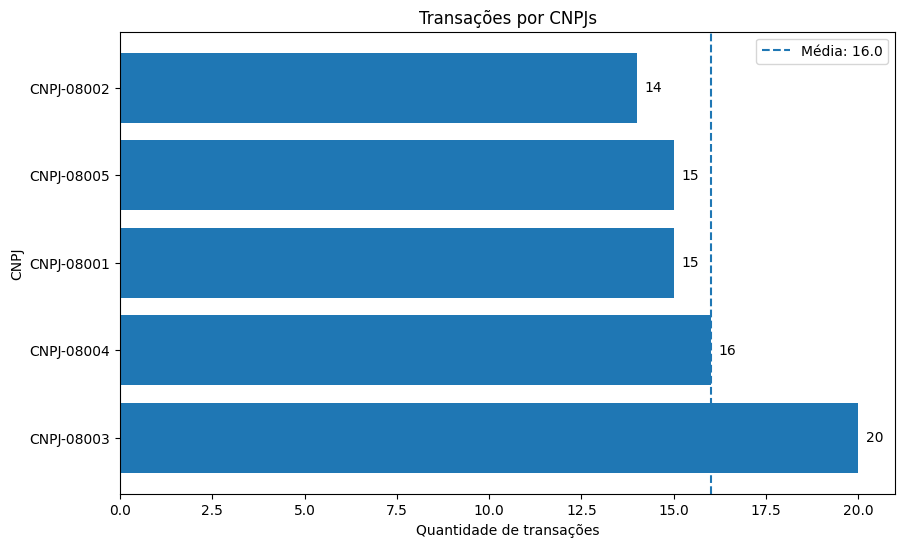

In [58]:
df_cnpj = df_master[df_master["CNPJ OK"].notna()]

cnpj_transacoes = (df_cnpj.groupby("CNPJ OK")["transacao_id"].count().reset_index())

cnpj_transacoes.rename(columns={"transacao_id":"quantidade_transacoes"},inplace=True)

cnpj_transacoes = cnpj_transacoes.sort_values(by="quantidade_transacoes",ascending=False)

top5_cnpj = cnpj_transacoes.head(5)

total_top5 = top5_cnpj["quantidade_transacoes"].sum()

top5_cnpj["quantidade_transacoes"] = top5_cnpj["quantidade_transacoes"].astype(int)

print("\nTotal de transações dos 5 principais CNPJs:", total_top5)
print("Média por CNPJ:", total_top5 / 5)

print(top5_cnpj)

media_transacoes = cnpj_transacoes["quantidade_transacoes"].mean()

print("Média de transações por CNPJ:", round(media_transacoes,2))

plt.figure(figsize=(10,6))
bars = plt.barh(top5_cnpj["CNPJ OK"],top5_cnpj["quantidade_transacoes"])
plt.title("Transações por CNPJs")
plt.ylabel("CNPJ")
plt.xlabel("Quantidade de transações")
for bar in bars:

    largura = bar.get_width()

    plt.text(largura + 0.2,bar.get_y() + bar.get_height()/2,f'{int(largura)}',va='center')

plt.axvline(media_transacoes,linestyle='--',label=f"Média: {media_transacoes:.1f}")
plt.legend()
plt.show()

## Investigação 6 — Forma de pagamento das transações

Pagamentos realizados **à vista** são mais difíceis de rastrear
do que operações financiadas por instituições financeiras.

Nesta análise verificamos se transações suspeitas
apresentam maior concentração de pagamentos à vista.

Uma alta proporção desse tipo de pagamento pode indicar
tentativas de evitar rastreamento financeiro.


Index(['comprador_id', 'renda_mensal_declarada', 'idade', 'estado_civil',
       'profissao', 'numero_imoveis_adquiridos', 'possui_restricao_credito',
       'pep', 'transacao_id', 'imovel_id', 'bairro', 'tipo_imovel', 'area_m2',
       'quartos', 'condicao', 'preco_total', 'preco_m2', 'comprador_cnpj',
       'forma_pagamento', 'ano_transacao', 'mes_transacao', 'dias_no_mercado',
       'CNPJ OK', 'data_transacao', 'preco_m2_referencia', 'variação',
       'é suspeito?', 'compra_suspeita?', 'maior_3_aquisicoes?',
       'varias_transacoes', 'dias_revenda'],
      dtype='str')
  compra_suspeita?  transacao_id
0              SIM           168


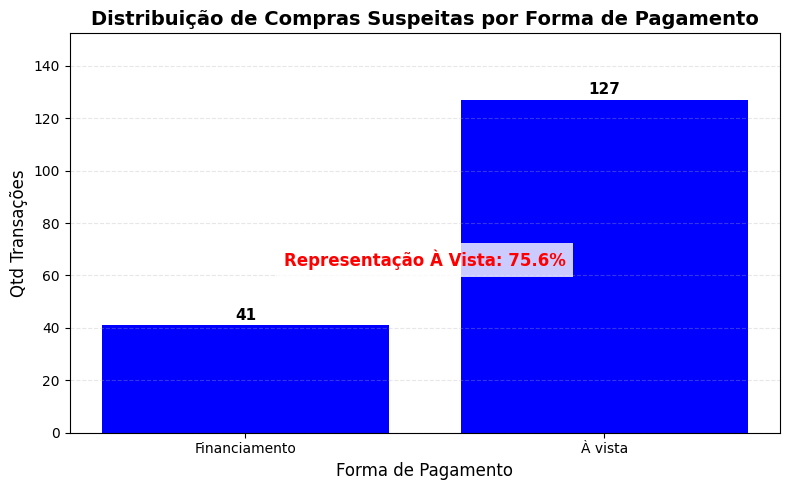

In [59]:
print(df_master.columns)

visao_1 = df_master[['transacao_id', 'forma_pagamento', 'compra_suspeita?']]
visao_1 = visao_1[visao_1['compra_suspeita?'] == 'SIM']

contagem_suspeitas = visao_1.groupby('compra_suspeita?')['transacao_id'].count().reset_index()
print(contagem_suspeitas)

visao_2 = df_master[df_master['compra_suspeita?'] == 'SIM']
df_plot = visao_2.groupby('forma_pagamento')['transacao_id'].count().reset_index()

total_suspeitas = df_plot['transacao_id'].sum()
valor_a_vista = df_plot[df_plot['forma_pagamento'] == 'À vista']['transacao_id'].values[0]
porcentagem = (valor_a_vista / total_suspeitas) * 100

plt.figure(figsize=(8, 5))
barras = plt.bar(df_plot['forma_pagamento'], df_plot['transacao_id'], color='blue')

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.text(df_plot.shape[0] / 2 - 0.5, max(df_plot['transacao_id']) / 2, f'Representação À Vista: {porcentagem:.1f}%',fontsize=12, color='red', fontweight='bold', ha='center',bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))

plt.title('Distribuição de Compras Suspeitas por Forma de Pagamento', fontsize=14, fontweight='bold')
plt.xlabel('Forma de Pagamento', fontsize=12)
plt.ylabel('Qtd Transações', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, max(df_plot['transacao_id']) * 1.2)
plt.tight_layout()
plt.show()

## Dossiê final de suspeitos

Após todas as análises investigativas,
consolidamos uma lista de possíveis suspeitos.

A lista inclui:

• CPFs envolvidos em compras com renda incompatível  
• compradores que adquiriram imóveis com sobrepreço  
• CNPJs envolvidos em transações recorrentes  

Esses registros representam **pontos de atenção para investigação
mais aprofundada por autoridades competentes**.


In [60]:
df_cpf_cnpj_compras_suspeitas_renda_baixa = df_master[df_master['compra_suspeita?']=='SIM']

cpfs_renda_baixa_compra_alta = (df_cpf_cnpj_compras_suspeitas_renda_baixa[['comprador_id']])

df_cpf_cnpj_pagos_acima_40 = df_master[df_master['é suspeito?']=="SIM"]

cpfs_pagos_acima_40 = df_cpf_cnpj_pagos_acima_40[['comprador_id']]

cnpj_suspeitos = df_master[df_master['CNPJ OK'].notna()]['CNPJ OK'].unique()
cnpj_suspeitos = pd.DataFrame(cnpj_suspeitos,columns=['comprador_id'])

cpf_cnpj_suspeitos_consolidados = pd.concat([cpfs_renda_baixa_compra_alta,cpfs_pagos_acima_40,cnpj_suspeitos],ignore_index=True)

cpf_cnpj_suspeitos_consolidados = (cpf_cnpj_suspeitos_consolidados.drop_duplicates())

print(cpf_cnpj_suspeitos_consolidados.info())

<class 'pandas.DataFrame'>
Index: 138 entries, 0 to 262
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   comprador_id  138 non-null    str  
dtypes: str(1)
memory usage: 2.2 KB
None


## Exportação dos resultados da investigação

Nesta etapa final exportamos a lista consolidada
de CPFs e CNPJs suspeitos para um arquivo CSV.

Esse arquivo representa o **resultado final da análise investigativa**
e pode ser utilizado como base para relatórios
ou investigações complementares.


In [63]:
nome_arquivo = 'LISTA_CPFS_CNPJS_SUSPEITOS.csv'

caminho_diretorio = (f'../data/{nome_arquivo}')

cpf_cnpj_suspeitos_consolidados.to_csv(caminho_diretorio,index=False,sep=';',encoding='utf-8-sig')

print(f"Arquivo exportado com sucesso para: {caminho_diretorio}")
print(f"Total de registros únicos: {len(cpf_cnpj_suspeitos_consolidados)}")

Arquivo exportado com sucesso para: ../data/LISTA_CPFS_CNPJS_SUSPEITOS.csv
Total de registros únicos: 138
